In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [5]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams['svg.fonttype'] = 'none'

In [7]:
Experiment1_Layout = pd.read_csv("~/Desktop/KATANA_PULL/blana/Alex/260411_POLR2A_Translation/260411_POLR2A_Translation.csv")
Experiment2_Layout = pd.read_csv("~/Desktop/KATANA_PULL/blana/Alex/260529_POLR2A_Translation/260529_POLR2A_Translation.csv")

## load quantification files from relevant directories, and assemble into data frames

In [8]:
Experiment1_Quantification_Dir = Path("/Users/alexandergillis/Desktop/KATANA_PULL/260411_POLR2A_Translation/20260415_185526_435/QUANTIFICATION/")
Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Dir / "*.csv"))
len(Experiment1_Quantification_Files)

1350

In [9]:
Experiment2_Quantification_Dir = Path("/Users/alexandergillis/Desktop/KATANA_PULL/260529_POLR2A_Translation/20260602_155614_678/QUANTIFICATION/")
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Dir / "*.csv"))
len(Experiment2_Quantification_Files)

1338

In [10]:
Experiment1_Nuclei_Quantification_Files = [i for i in Experiment1_Quantification_Files if "nuclei_" in i]
Experiment1_Cell_Quantification_Files = [i for i in Experiment1_Quantification_Files if "cells_" in i]
Experiment1_FISH_Quantification_Files = [i for i in Experiment1_Quantification_Files if "spots_" in i]

Experiment2_Nuclei_Quantification_Files = [i for i in Experiment2_Quantification_Files if "nuclei_" in i]
Experiment2_Cell_Quantification_Files = [i for i in Experiment2_Quantification_Files if "cells_" in i]
Experiment2_FISH_Quantification_Files = [i for i in Experiment2_Quantification_Files if "spots_" in i]

### load per nucleus quantification for both experiments

In [11]:
qdfs = list()


for f in tqdm(Experiment1_Nuclei_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Quantifcation_PerNucleus = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Quantifcation_PerNucleus['file'].tolist()


wellnames = [f[7:13] for f in files]
Experiment1_Quantifcation_PerNucleus['well'] = wellnames

fovs = [f[47:51] for f in files]
Experiment1_Quantifcation_PerNucleus['fov'] = fovs

100%|████████████████████████████████████████| 450/450 [00:01<00:00, 261.70it/s]


In [12]:
Experiment1_Quantifcation_PerNucleus = Experiment1_Quantifcation_PerNucleus.merge(Experiment1_Layout, how = 'left', left_on = "well", right_on = "WELL")

In [13]:
Experiment1_Quantifcation_PerNucleus = Experiment1_Quantifcation_PerNucleus.query('Nuclei_3D_is_border == False')

In [14]:
qdfs = list()


for f in tqdm(Experiment2_Nuclei_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Quantifcation_PerNucleus = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Quantifcation_PerNucleus['file'].tolist()


wellnames = [f[7:13] for f in files]
Experiment2_Quantifcation_PerNucleus['well'] = wellnames

fovs = [f[47:51] for f in files]
Experiment2_Quantifcation_PerNucleus['fov'] = fovs

100%|████████████████████████████████████████| 446/446 [00:01<00:00, 283.86it/s]


In [15]:
Experiment2_Quantifcation_PerNucleus = Experiment2_Quantifcation_PerNucleus.merge(Experiment2_Layout, how = 'left', left_on = "well", right_on = "WELL")

### load per fish spot quantification for both experiments

In [16]:
qdfs = list()


for f in tqdm(Experiment1_FISH_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment1_Quantifcation_PerSpot = pd.concat(qdfs, ignore_index=True)

files = Experiment1_Quantifcation_PerSpot['file'].tolist()


wellnames = [f[10:16] for f in files]
Experiment1_Quantifcation_PerSpot['well'] = wellnames

fovs = [f[47:51] for f in files]
Experiment1_Quantifcation_PerSpot['fov'] = fovs

100%|████████████████████████████████████████| 450/450 [00:01<00:00, 392.07it/s]


In [17]:
# filter for fish spots which are not nuclear, but are contained in a segmented cell
Experiment1_Quantifcation_PerSpot = Experiment1_Quantifcation_PerSpot.query('Spots_3D_intensity_Nuclei == 0 & Spots_3D_intensity_Cells != 0')
Experiment1_Quantifcation_PerSpot = Experiment1_Quantifcation_PerSpot.merge(Experiment1_Layout, how = 'left', left_on = "well", right_on = "WELL")

In [18]:
qdfs = list()


for f in tqdm(Experiment2_FISH_Quantification_Files):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

Experiment2_Quantifcation_PerSpot = pd.concat(qdfs, ignore_index=True)

files = Experiment2_Quantifcation_PerSpot['file'].tolist()


wellnames = [f[10:16] for f in files]
Experiment2_Quantifcation_PerSpot['well'] = wellnames

fovs = [f[47:51] for f in files]
Experiment2_Quantifcation_PerSpot['fov'] = fovs

100%|████████████████████████████████████████| 446/446 [00:01<00:00, 400.01it/s]


In [19]:
# filter for fish spots which are not nuclear, but are contained in a segmented cell
Experiment2_Quantifcation_PerSpot = Experiment2_Quantifcation_PerSpot.query('Spots_3D_intensity_Nuclei == 0 & Spots_3D_intensity_Cells != 0')
Experiment2_Quantifcation_PerSpot = Experiment2_Quantifcation_PerSpot.merge(Experiment2_Layout, how = 'left', left_on = "well", right_on = "WELL")

## plot mean nuclear intensities of mCherry immuofluorescence

### confirm mCherryPOLR2A adaptation in mAC/mCherryPOLR2A cells

In [20]:
Experiment1_Quantifcation_PerNucleus.PRIMARY.unique()

array(['No primary', 'Total Pol II (F12)', 'mCherry (abcam)'],
      dtype=object)

<Axes: xlabel='CELL', ylabel='Nuclei_3D_intensity_mean_561'>

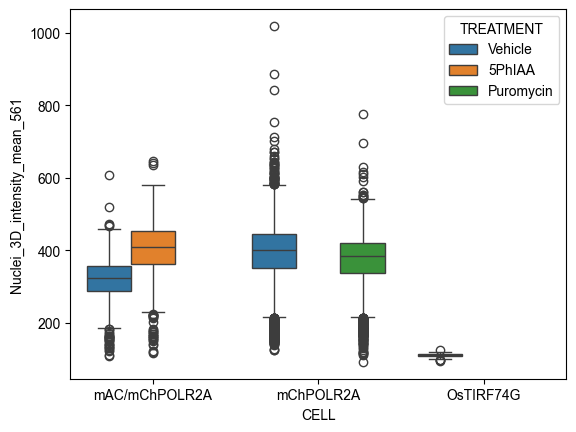

In [21]:
sns.boxplot(Experiment1_Quantifcation_PerNucleus.query('PRIMARY == "mCherry (abcam)"'),
            x = 'CELL',
            hue = 'TREATMENT', dodge = True,
            y = 'Nuclei_3D_intensity_mean_561')

In [22]:
Experiment1_Quantifcation_PerNucleus.query('WELL == "Well02"').Nuclei_3D_intensity_mean_561.mean(), Experiment1_Quantifcation_PerNucleus.query('WELL == "Well03"').Nuclei_3D_intensity_mean_561.mean()

(111.30485062398377, 419.4784234164994)

<Axes: xlabel='Nuclei_3D_physical_volume_pL', ylabel='Density'>

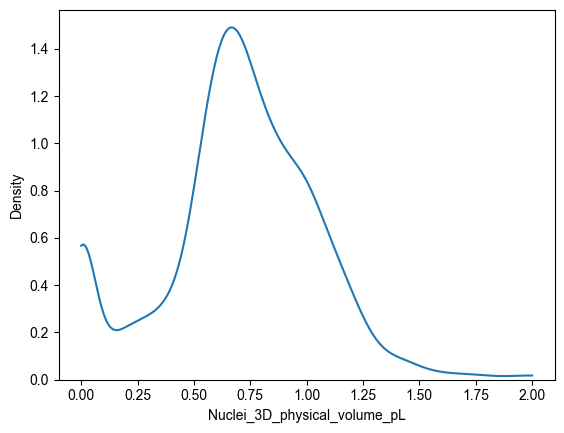

In [23]:
sns.kdeplot(Experiment1_Quantifcation_PerNucleus.Nuclei_3D_physical_volume_pL, clip = (0,2))

<Axes: xlabel='Nuclei_3D_physical_volume_pL', ylabel='Density'>

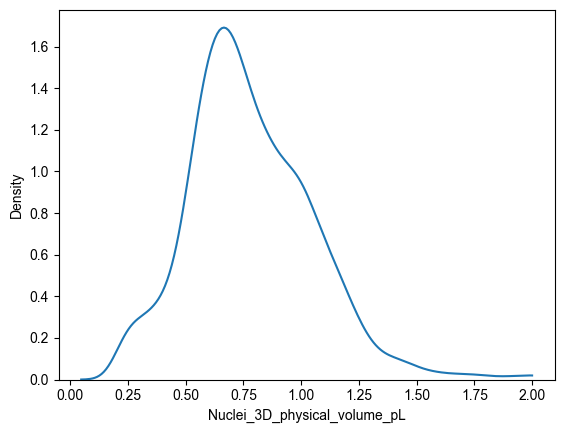

In [24]:
sns.kdeplot(Experiment1_Quantifcation_PerNucleus.query('Nuclei_3D_physical_volume_pL > 0.2').Nuclei_3D_physical_volume_pL, clip = (0,2))

In [25]:
## filter out cells with very small nuclei segmented 
Experiment1_Quantifcation_PerNucleus = Experiment1_Quantifcation_PerNucleus.query('Nuclei_3D_physical_volume_pL > 0.2')

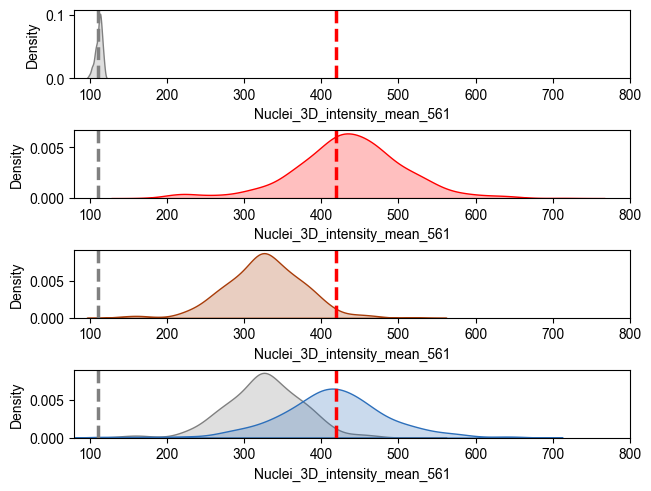

In [26]:
f, a = plt.subplots(nrows = 4, layout = 'constrained')

sns.kdeplot(Experiment1_Quantifcation_PerNucleus.query('WELL == "Well02"'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[0],
            color = 'grey', fill = True)

sns.kdeplot(Experiment1_Quantifcation_PerNucleus.query('WELL == "Well03"'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[1],
            color = 'red', fill = True, common_norm = False)

sns.kdeplot(Experiment1_Quantifcation_PerNucleus.query('WELL == "Well04"'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[2],
            color = 'xkcd:rust', fill = True, common_norm = False)


sns.kdeplot(Experiment1_Quantifcation_PerNucleus.query('WELL == "Well04"'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[3],
            color = 'grey', fill = True, common_norm = False)


sns.kdeplot(Experiment1_Quantifcation_PerNucleus.query('WELL == "Well05"'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[3],
            color = 'xkcd:medium blue', fill = True, common_norm = False)



for i in range(4):
    a[i].set_xlim(80,800)
    a[i].axvline(111.3, color = 'grey', linestyle = '--', linewidth = 2.5)
    a[i].axvline(419.5, color = 'red', linestyle = '--', linewidth = 2.5)

<Axes: xlabel='CELL', ylabel='Nuclei_3D_intensity_mean_561'>

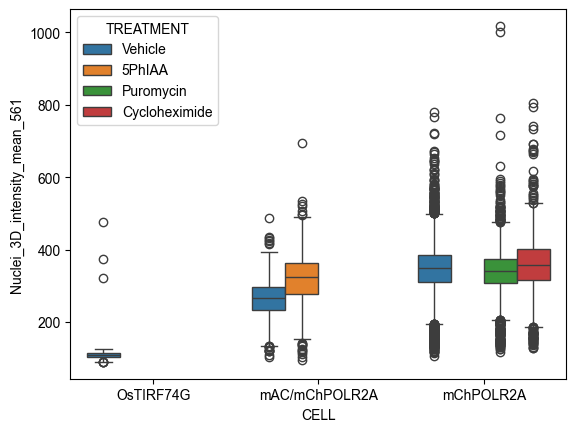

In [27]:
sns.boxplot(Experiment2_Quantifcation_PerNucleus,
            x = 'CELL',
            hue = 'TREATMENT', dodge = True,
            y = 'Nuclei_3D_intensity_mean_561')

In [28]:
Experiment2_Layout

,WELL,CELL,ATTO565_PROBE,ATTO633_PROBE,TREATMENT,PRIMARY,SECONDARY
0,Well01,OsTIRF74G,No probe,POLR2A,Vehicle,No primary,Goat anti-rabbit Alexa568
1,Well02,OsTIRF74G,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
2,Well03,mChPOLR2A,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
3,Well04,mAC/mChPOLR2A,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
4,Well05,mAC/mChPOLR2A,No probe,POLR2A,5PhIAA,mCherry (abcam),Goat anti-rabbit Alexa568
5,Well06,OsTIRF74G,No probe,POLR2A,Vehicle,No primary,No secondary
6,Well07,mChPOLR2A,No probe,POLR2A,Puromycin,mCherry (abcam),Goat anti-rabbit Alexa568
7,Well08,mChPOLR2A,No probe,POLR2A,Cycloheximide,mCherry (abcam),Goat anti-rabbit Alexa568
8,Well09,mChPOLR2A,No probe,POLR2B odd,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
9,Well10,mChPOLR2A,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568


In [29]:
## filter out cells with very small nuclei segmented
Experiment2_Quantifcation_PerNucleus = Experiment2_Quantifcation_PerNucleus.query('Nuclei_3D_physical_volume_pL > 0.2')

<Axes: xlabel='Nuclei_3D_physical_volume_pL', ylabel='Density'>

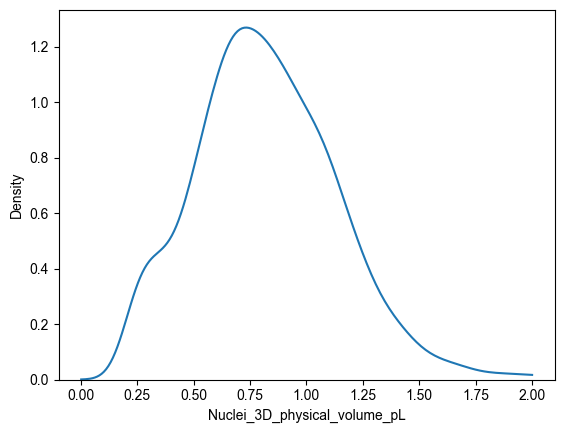

In [30]:
sns.kdeplot(Experiment2_Quantifcation_PerNucleus.Nuclei_3D_physical_volume_pL, clip = (0,2))

In [31]:
Experiment2_Quantifcation_PerNucleus.query('WELL == "Well02"').Nuclei_3D_intensity_mean_561.mean()

111.41607717316614

In [32]:
Experiment2_Quantifcation_PerNucleus.query('WELL in ["Well03","Well10"]').Nuclei_3D_intensity_mean_561.mean()

347.35125902030944

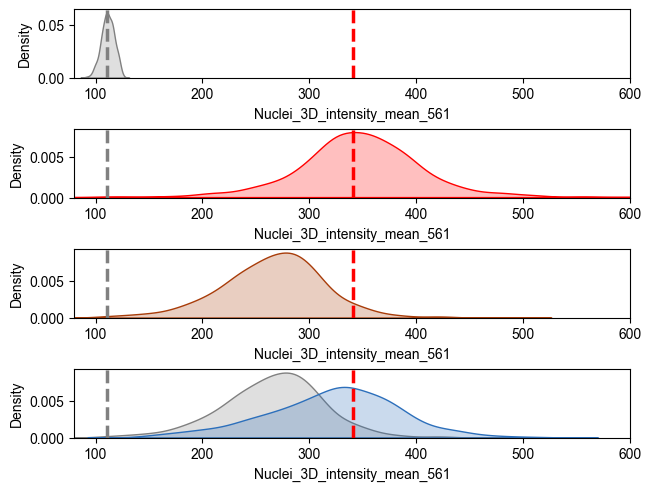

In [33]:
f, a = plt.subplots(nrows = 4, layout = 'constrained')

sns.kdeplot(Experiment2_Quantifcation_PerNucleus.query('WELL == "Well02"'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[0],
            color = 'grey', fill = True)

sns.kdeplot(Experiment2_Quantifcation_PerNucleus.query('WELL in ["Well03","Well10"]'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[1],
            color = 'red', fill = True, common_norm = False)

sns.kdeplot(Experiment2_Quantifcation_PerNucleus.query('WELL in ["Well04","Well11"]'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[2],
            color = 'xkcd:rust', fill = True, common_norm = False)


sns.kdeplot(Experiment2_Quantifcation_PerNucleus.query('WELL in ["Well04","Well11"]'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[3],
            color = 'grey', fill = True, common_norm = False)


sns.kdeplot(Experiment2_Quantifcation_PerNucleus.query('WELL in ["Well05","Well12"]'),
            x = 'Nuclei_3D_intensity_mean_561',
            ax = a[3],
            color = 'xkcd:medium blue', fill = True, common_norm = False)



for i in range(4):
    a[i].set_xlim(80,600)
    a[i].axvline(110.7, color = 'grey', linestyle = '--', linewidth = 2.5)
    a[i].axvline(340.5, color = 'red', linestyle = '--', linewidth = 2.5)

## plot intensities of mCherry immunofluorescence at smFISH spots

In [34]:
Experiment1_Layout.query('PRIMARY == "mCherry (abcam)"')

,WELL,CELL,ATTO565_PROBE,ATTO633_PROBE,TREATMENT,PRIMARY,SECONDARY
1,Well02,OsTIRF74G,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
2,Well03,mChPOLR2A,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
3,Well04,mAC/mChPOLR2A,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
4,Well05,mAC/mChPOLR2A,No probe,POLR2A,5PhIAA,mCherry (abcam),Goat anti-rabbit Alexa568
7,Well08,mChPOLR2A,No probe,POLR2A,Puromycin,mCherry (abcam),Goat anti-rabbit Alexa568
14,Well15,mChPOLR2A,No probe,CTCF,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
15,Well16,mChPOLR2A,No probe,POLR2B,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568


In [35]:
Experiment2_Layout.query('PRIMARY == "mCherry (abcam)"')

,WELL,CELL,ATTO565_PROBE,ATTO633_PROBE,TREATMENT,PRIMARY,SECONDARY
1,Well02,OsTIRF74G,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
2,Well03,mChPOLR2A,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
3,Well04,mAC/mChPOLR2A,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
4,Well05,mAC/mChPOLR2A,No probe,POLR2A,5PhIAA,mCherry (abcam),Goat anti-rabbit Alexa568
6,Well07,mChPOLR2A,No probe,POLR2A,Puromycin,mCherry (abcam),Goat anti-rabbit Alexa568
7,Well08,mChPOLR2A,No probe,POLR2A,Cycloheximide,mCherry (abcam),Goat anti-rabbit Alexa568
8,Well09,mChPOLR2A,No probe,POLR2B odd,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
9,Well10,mChPOLR2A,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
10,Well11,mAC/mChPOLR2A,No probe,POLR2A,Vehicle,mCherry (abcam),Goat anti-rabbit Alexa568
11,Well12,mAC/mChPOLR2A,No probe,POLR2A,5PhIAA,mCherry (abcam),Goat anti-rabbit Alexa568


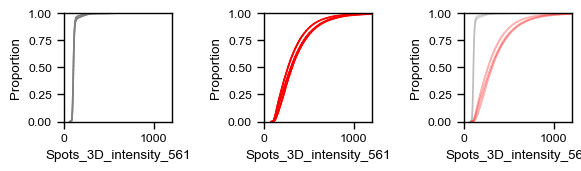

In [36]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,1.6), ncols = 3, layout = 'constrained')

pal = sns.color_palette([sns.color_palette('tab10')[0], sns.color_palette('tab10')[7]])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well02"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well02"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well02"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well02"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.3)

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.3)

for i in range(3):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)

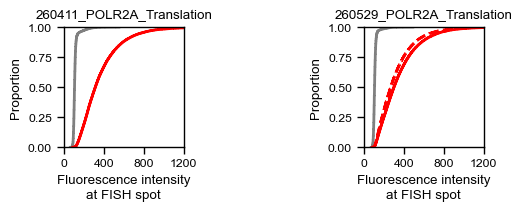

In [37]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

pal = sns.color_palette([sns.color_palette('tab10')[0], sns.color_palette('tab10')[7]])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well02"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0], linewidth = 2)

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], linewidth = 2)

g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well02"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[1], linewidth = 2)

g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linewidth = 2)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', linewidth = 2)

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

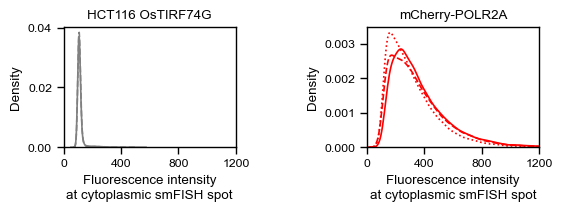

In [38]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

g = sns.kdeplot(Experiment1_Quantifcation_PerSpot.query('well == "Well02"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0], clip = (0,1200), common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well02"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0], clip = (0,1200), linestyle ='--', common_norm = False)

g = sns.kdeplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), linestyle = '--', common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), linestyle = ':', common_norm = False)

a[0].set_title('HCT116 OsTIRF74G')
a[1].set_title('mCherry-POLR2A')

for i in range(2):
    a[i].set_box_aspect(0.7)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat cytoplasmic smFISH spot')

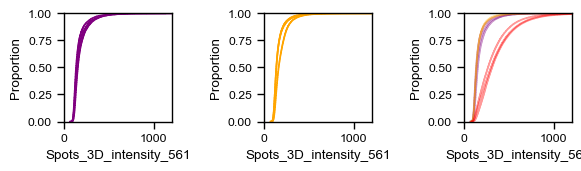

In [39]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,1.6), ncols = 3, layout = 'constrained')

pal = sns.color_palette([sns.color_palette('tab10')[0], sns.color_palette('tab10')[7]])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well13"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well16"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well16"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well09"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well14"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well13"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well16"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well19"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well09"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well14"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)

for i in range(3):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)

In [40]:
Experiment1_Quantifcation_PerSpot.query('well == "Well15"').ATTO633_PROBE.unique()

array(['CTCF'], dtype=object)

In [41]:
Experiment1_Quantifcation_PerSpot.query('well == "Well16"').ATTO633_PROBE.unique()

array(['POLR2B'], dtype=object)

In [42]:
Experiment2_Quantifcation_PerSpot.query('well == "Well13"').ATTO633_PROBE.unique()

array(['CTCF'], dtype=object)

In [43]:
Experiment2_Quantifcation_PerSpot.query('well == "Well16"').ATTO633_PROBE.unique()

array(['CTCF'], dtype=object)

In [44]:
Experiment2_Quantifcation_PerSpot.query('well == "Well09"').ATTO633_PROBE.unique()

array(['POLR2B odd'], dtype=object)

In [45]:
Experiment2_Quantifcation_PerSpot.query('well == "Well14"').ATTO633_PROBE.unique()

array(['POLR2B odd'], dtype=object)

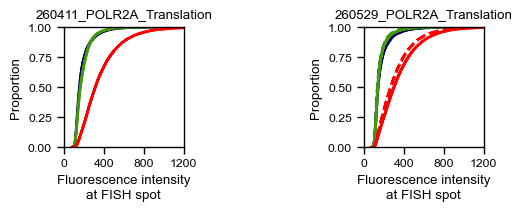

In [46]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well15"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[0], linewidth = 2)
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well16"'), color = 'xkcd:grass green', x = 'Spots_3D_intensity_561', ax = a[0], linewidth = 2)
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], linewidth = 2)


g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well13"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[1], linewidth = 2)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well16"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', linewidth = 2)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well09"'), color = 'xkcd:grass green', x = 'Spots_3D_intensity_561', ax = a[1], linewidth = 2)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well14"'), color = 'xkcd:grass green', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', linewidth = 2)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linewidth = 2)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', linewidth = 2)

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

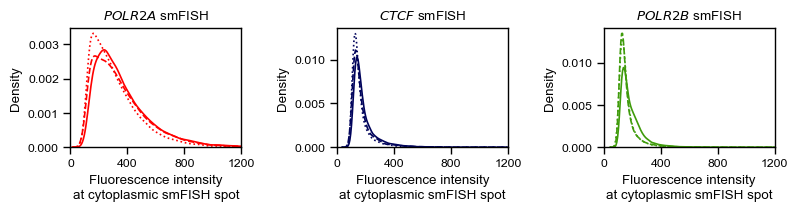

In [47]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (8,2), ncols = 3, layout = 'constrained')

g = sns.kdeplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], clip = (0,1200), common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], clip = (0,1200), linestyle = '--', common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], clip = (0,1200), linestyle = ':', common_norm = False)

g = sns.kdeplot(Experiment1_Quantifcation_PerSpot.query('well == "Well15"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well13"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), linestyle = '--', common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well16"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), linestyle = ':', common_norm = False)

g = sns.kdeplot(Experiment1_Quantifcation_PerSpot.query('well == "Well16"'), color = 'xkcd:grass green', x = 'Spots_3D_intensity_561', ax = a[2], clip = (0,1200), common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well09"'), color = 'xkcd:grass green', x = 'Spots_3D_intensity_561', ax = a[2], clip = (0,1200), linestyle = '--', common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well14"'), color = 'xkcd:grass green', x = 'Spots_3D_intensity_561', ax = a[2], clip = (0,1200), linestyle = ':', common_norm = False)

a[0].set_title('$POLR2A$ smFISH')
a[1].set_title('$CTCF$ smFISH')
a[2].set_title('$POLR2B$ smFISH')

for i in range(3):
    a[i].set_box_aspect(0.7)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat cytoplasmic smFISH spot')

## ECDF plots for paper

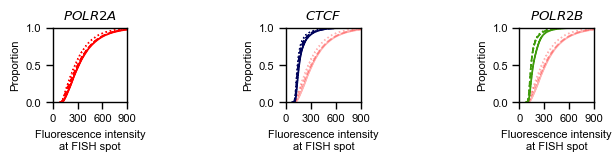

In [48]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (7,1.5), ncols = 3, layout = 'constrained')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = ':')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = ':', alpha = 0.3)

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well15"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well13"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well16"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = ':')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], linestyle = '--', alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], linestyle = ':', alpha = 0.3)

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well16"'), color = 'xkcd:grass green', x = 'Spots_3D_intensity_561', ax = a[2])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well09"'), color = 'xkcd:grass green', x = 'Spots_3D_intensity_561', ax = a[2], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well14"'), color = 'xkcd:grass green', x = 'Spots_3D_intensity_561', ax = a[2], linestyle = ':')


for i in range(3):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,900)
    a[i].set_xticks([0,300,600,900])
    a[i].tick_params(axis = 'x', labelsize = 8)
    a[i].tick_params(axis = 'y', labelsize = 8)
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot', fontsize = 8)
    a[i].set_ylabel('Proportion', fontsize = 8)

a[0].set_title('$POLR2A$')
a[1].set_title('$CTCF$')
a[2].set_title('$POLR2B$')

plt.savefig('ecdf_mcherry_if_probes.svg')

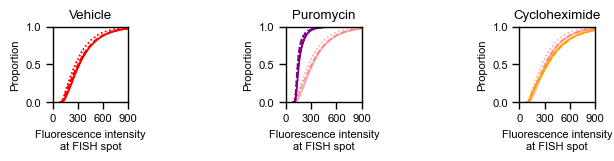

In [49]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (7,1.5), ncols = 3, layout = 'constrained')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = ':')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = ':', alpha = 0.3)

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well08"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well07"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = ':')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], linestyle = '--', alpha = 0.3)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], linestyle = ':', alpha = 0.3)

g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well08"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[2])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well17"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[2], linestyle = '--')


for i in range(3):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,900)
    a[i].set_xticks([0,300,600,900])
    a[i].tick_params(axis = 'x', labelsize = 8)
    a[i].tick_params(axis = 'y', labelsize = 8)
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot', fontsize = 8)
    a[i].set_ylabel('Proportion', fontsize = 8)

a[0].set_title('Vehicle')
a[1].set_title('Puromycin')
a[2].set_title('Cycloheximide')

plt.savefig('ecdf_mcherry_if_treatment.svg')

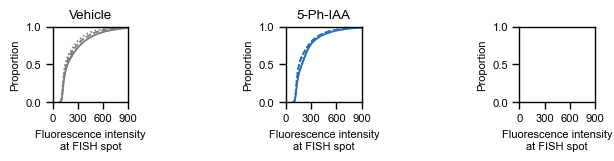

In [50]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (7,1.5), ncols = 3, layout = 'constrained')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well04"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well04"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well11"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = ':')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well05"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well05"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well12"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = ':')



for i in range(3):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,900)
    a[i].set_xticks([0,300,600,900])
    a[i].tick_params(axis = 'x', labelsize = 8)
    a[i].tick_params(axis = 'y', labelsize = 8)
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot', fontsize = 8)
    a[i].set_ylabel('Proportion', fontsize = 8)

a[0].set_title('Vehicle')
a[1].set_title('5-Ph-IAA')

plt.savefig('ecdf_macmcherry_veh_5ph.svg')

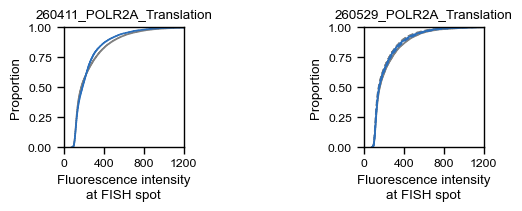

In [51]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

pal = sns.color_palette([sns.color_palette('tab10')[0], sns.color_palette('tab10')[7]])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well04"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well05"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[0])


g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well04"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well11"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well05"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[1],)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well12"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

plt.savefig('macmchpolr2a_veh_5ph_mcherryFI_ecdf.pdf')    

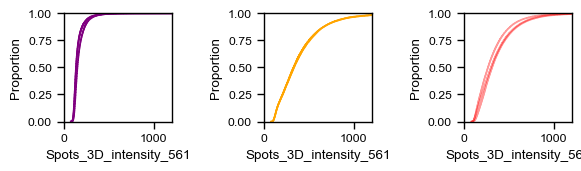

In [52]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,1.6), ncols = 3, layout = 'constrained')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well08"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well07"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])

g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well08"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well17"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[2], alpha = 0.4)

for i in range(3):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)

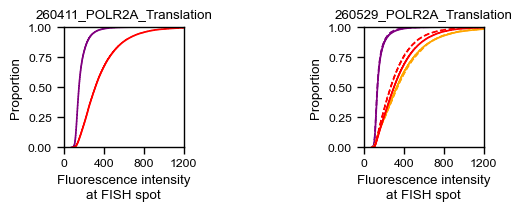

In [53]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well08"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0])


g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well07"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well08"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well17"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1],)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

plt.savefig('mchpolr2a_veh_puro_chx_mcherryFI_ecdf.pdf')

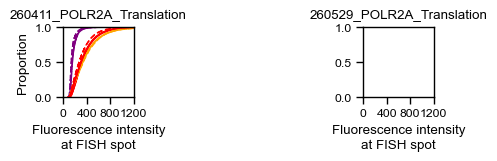

In [54]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,1.5), ncols = 2, layout = 'constrained')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well08"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well07"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = ':')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well08"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well17"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0],)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], linestyle = '--')

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

plt.savefig('mchpolr2a_veh_puro_chx_mcherryFI_ecdf.pdf')

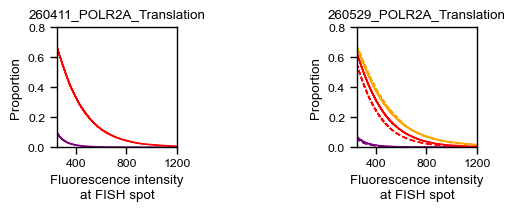

In [55]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well08"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0], complementary = True)
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], complementary = True)


g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well07"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], complementary = True)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', complementary = True)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well08"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1], complementary = True)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well17"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', complementary = True)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], complementary = True)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', complementary = True)

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_ylim(0, 0.8)
    a[i].set_xlim(250,1200)
    a[i].set_xticks([400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

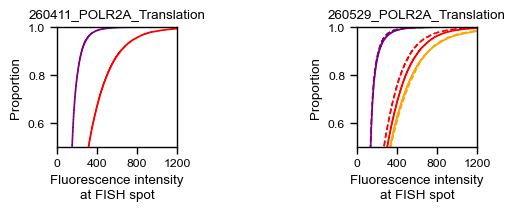

In [56]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well08"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0])


g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well07"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well08"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well17"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1],)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)
    a[i].set_ylim(0.5,1)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

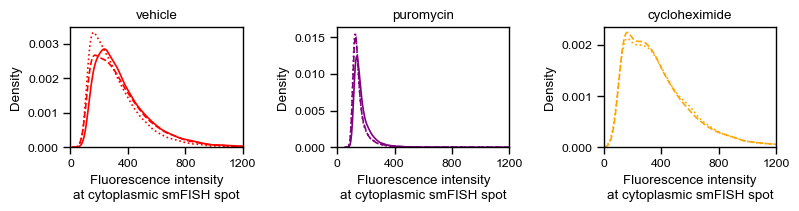

In [57]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (8,2), ncols = 3, layout = 'constrained')

g = sns.kdeplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], clip = (0,1200), common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], clip = (0,1200), linestyle = '--', common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], clip = (0,1200), linestyle = ':', common_norm = False)


g = sns.kdeplot(Experiment1_Quantifcation_PerSpot.query('well == "Well08"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well07"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), linestyle = '--', common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), linestyle = ':', common_norm = False)

g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well08"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[2], clip = (0,1200), linestyle = '--', common_norm = False)
g = sns.kdeplot(Experiment2_Quantifcation_PerSpot.query('well == "Well17"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[2], clip = (0,1200), linestyle = ':', common_norm = False)

a[0].set_title('vehicle')
a[1].set_title('puromycin')
a[2].set_title('cycloheximide')

for i in range(3):
    a[i].set_box_aspect(0.7)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat cytoplasmic smFISH spot')

plt.savefig('mchpolr2a_veh_puro_chx_mcherryFI_kde.pdf')

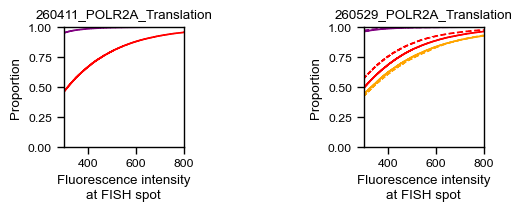

In [58]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

pal = sns.color_palette([sns.color_palette('tab10')[0], sns.color_palette('tab10')[7]])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well08"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0])


g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well07"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well15"'), color = 'purple', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well08"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well17"'), color = 'orange', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1],)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well10"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_xlim(300, 800)
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

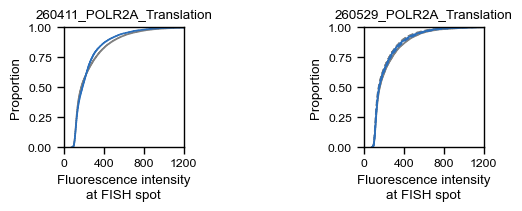

In [59]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

pal = sns.color_palette([sns.color_palette('tab10')[0], sns.color_palette('tab10')[7]])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well04"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0])
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well05"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[0])


g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well04"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[1])
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well11"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well05"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[1],)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well12"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--')

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

plt.savefig('macmchpolr2a_veh_5ph_mcherryFI_ecdf.pdf')    

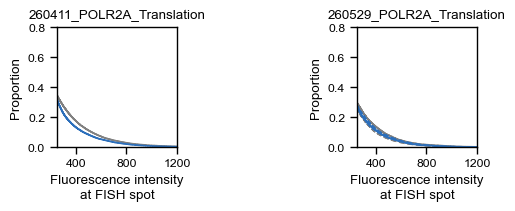

In [60]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (6,2), ncols = 2, layout = 'constrained')

pal = sns.color_palette([sns.color_palette('tab10')[0], sns.color_palette('tab10')[7]])

g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well04"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[0], complementary = True)
g = sns.ecdfplot(Experiment1_Quantifcation_PerSpot.query('well == "Well05"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[0], complementary = True)


g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well04"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[1], complementary = True)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well11"'), color = 'grey', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', complementary = True)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well05"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[1], complementary = True)
g = sns.ecdfplot(Experiment2_Quantifcation_PerSpot.query('well == "Well12"'), color = 'xkcd:medium blue', x = 'Spots_3D_intensity_561', ax = a[1], linestyle = '--', complementary = True)

a[0].set_title('260411_POLR2A_Translation')
a[1].set_title('260529_POLR2A_Translation')

for i in range(2):
    a[i].set_box_aspect(1)
    a[i].set_ylim(0,0.8)
    a[i].set_xlim(250,1200)
    a[i].set_xticks([400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat FISH spot')

#plt.savefig('macmchpolr2a_veh_5ph_mcherryFI_ecdf.pdf')    

## evaluate colocalisation percentage at variable cutoffs per replicate

In [61]:
variable_cutoffs = np.linspace(85,100,60)

In [102]:
## caluclate cutoff using negative control probesets
## vary from 100th to 85th percentile of fluorescent intensity at POLR2B & CTCF transcript points

In [103]:
e1_cs = []
e2_cs = []

for t in variable_cutoffs:
    e1_c_1 = np.percentile(Experiment1_Quantifcation_PerSpot.query('well == "Well15"').Spots_3D_intensity_561, t)
    e1_c_2 = np.percentile(Experiment1_Quantifcation_PerSpot.query('well == "Well16"').Spots_3D_intensity_561, t)
    e1_c = np.mean([e1_c_1, e1_c_2])
    e1_cs.append(e1_c)
    
    e2_c_1 = np.percentile(Experiment2_Quantifcation_PerSpot.query('well == "Well13"').Spots_3D_intensity_561, t)
    e2_c_2 = np.percentile(Experiment2_Quantifcation_PerSpot.query('well == "Well16"').Spots_3D_intensity_561, t)
    e2_c_3 = np.percentile(Experiment2_Quantifcation_PerSpot.query('well == "Well09"').Spots_3D_intensity_561, t)
    e2_c_4 = np.percentile(Experiment2_Quantifcation_PerSpot.query('well == "Well14"').Spots_3D_intensity_561, t)
    e2_c = np.mean([e2_c_1, e2_c_2, e2_c_3, e2_c_4])
    e2_cs.append(e2_c)

In [104]:
Experiment1_Thresholds = pd.DataFrame({'percentile' : variable_cutoffs, 'cutoff' : e1_cs})
Experiment2_Thresholds = pd.DataFrame({'percentile' : variable_cutoffs, 'cutoff' : e2_cs})

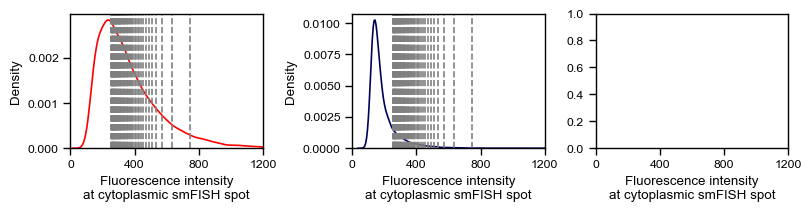

In [110]:
sns.set_context('paper')

f, a = plt.subplots(figsize = (8,2), ncols = 3, layout = 'constrained')

g = sns.kdeplot(Experiment1_Quantifcation_PerSpot.query('well == "Well03"'), color = 'red', x = 'Spots_3D_intensity_561', ax = a[0], clip = (0,1200), common_norm = False)

g = sns.kdeplot(Experiment1_Quantifcation_PerSpot.query('well == "Well15"'), color = 'xkcd:dark blue', x = 'Spots_3D_intensity_561', ax = a[1], clip = (0,1200), common_norm = False)

for c in Experiment1_Thresholds.cutoff:
    a[0].axvline(c, color = 'grey', linestyle = '--')
    a[1].axvline(c, color = 'grey', linestyle = '--')

for i in range(3):
    a[i].set_box_aspect(0.7)
    a[i].set_xlim(0,1200)
    a[i].set_xticks([0,400,800,1200])
    a[i].set_xlabel('Fluorescence intensity\nat cytoplasmic smFISH spot')

In [111]:
## calculate colocalisation of mCherry immunofluorescence with smFISH spot at all cutoffs

In [64]:
def calc_pct(df, p, c):
    dfe = df
    dfe['positive'] = dfe.Spots_3D_intensity_561  > c
    dfe = df[['well', 'positive']].groupby('well').mean().reset_index()
    dfe['cutoff'] = c
    dfe['percentile'] = p
    return dfe

In [65]:
experiment1_colocal_per_threshold = []

for i,r in Experiment1_Thresholds.iterrows():
    d = calc_pct(Experiment1_Quantifcation_PerSpot, r.percentile, r.cutoff)
    experiment1_colocal_per_threshold.append(d)
    
experiment1_colocal_per_threshold = pd.concat(experiment1_colocal_per_threshold)
experiment1_colocal_per_threshold = experiment1_colocal_per_threshold.merge(Experiment1_Layout, left_on = 'well', right_on = 'WELL')
experiment1_colocal_per_threshold['EXPERIMENT'] = '260411_POLR2A_Translation'

In [66]:
experiment2_colocal_per_threshold = []

for i,r in Experiment2_Thresholds.iterrows():
    d = calc_pct(Experiment2_Quantifcation_PerSpot, r.percentile, r.cutoff)
    experiment2_colocal_per_threshold.append(d)
    
experiment2_colocal_per_threshold = pd.concat(experiment2_colocal_per_threshold)
experiment2_colocal_per_threshold = experiment2_colocal_per_threshold.merge(Experiment2_Layout, left_on = 'well', right_on = 'WELL')
experiment2_colocal_per_threshold['EXPERIMENT'] = '260529_POLR2A_Translation'

In [67]:
Colocalisation_Per_Threshold = pd.concat([experiment1_colocal_per_threshold,experiment2_colocal_per_threshold])
Colocalisation_Per_Threshold['WELL_UNIQUE'] = Colocalisation_Per_Threshold['EXPERIMENT'] + Colocalisation_Per_Threshold['WELL']

In [68]:
Colocalisation_Per_Threshold['ATTO633_PROBE_NAME'] = Colocalisation_Per_Threshold.ATTO633_PROBE.map(dict(zip(['POLR2A', 'CTCF', 'POLR2B', 'No probe', 'POLR2B odd'], ['POLR2A', 'CTCF', 'POLR2B', 'No probe', 'POLR2B'])))

In [69]:
mch_veh_wells = Colocalisation_Per_Threshold.query('CELL == "mChPOLR2A" & ATTO633_PROBE == "POLR2A" & TREATMENT == "Vehicle" & PRIMARY == "mCherry (abcam)"').WELL_UNIQUE.unique()
mch_chx_wells = Colocalisation_Per_Threshold.query('CELL == "mChPOLR2A" & ATTO633_PROBE == "POLR2A" & TREATMENT == "Cycloheximide" & PRIMARY == "mCherry (abcam)"').WELL_UNIQUE.unique()
mch_puro_wells = Colocalisation_Per_Threshold.query('CELL == "mChPOLR2A" & ATTO633_PROBE == "POLR2A" & TREATMENT == "Puromycin" & PRIMARY == "mCherry (abcam)"').WELL_UNIQUE.unique()

mch_polr2b_wells = Colocalisation_Per_Threshold.query('CELL == "mChPOLR2A" & ATTO633_PROBE_NAME == "POLR2B" & TREATMENT == "Vehicle" & PRIMARY == "mCherry (abcam)"').WELL_UNIQUE.unique()
mch_ctcf_wells = Colocalisation_Per_Threshold.query('CELL == "mChPOLR2A" & ATTO633_PROBE == "CTCF" & TREATMENT == "Vehicle" & PRIMARY == "mCherry (abcam)"').WELL_UNIQUE.unique()

macmch_veh_wells = Colocalisation_Per_Threshold.query('CELL == "mAC/mChPOLR2A" & ATTO633_PROBE == "POLR2A" & TREATMENT == "Vehicle" & PRIMARY == "mCherry (abcam)"').WELL_UNIQUE.unique()
macmch_5ph_wells = Colocalisation_Per_Threshold.query('CELL == "mAC/mChPOLR2A" & ATTO633_PROBE == "POLR2A" & TREATMENT == "5PhIAA" & PRIMARY == "mCherry (abcam)"').WELL_UNIQUE.unique()

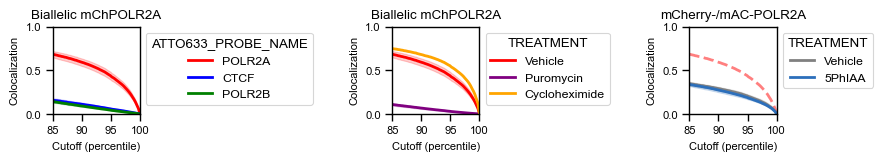

In [70]:
f, a = plt.subplots(ncols = 3, figsize = (9,1.5), layout = 'constrained')

compare_probes = Colocalisation_Per_Threshold.query('WELL_UNIQUE in @mch_veh_wells | WELL_UNIQUE in @mch_polr2b_wells  | WELL_UNIQUE in @mch_ctcf_wells')
palette1 = sns.color_palette(['red', 'blue', 'green'])
h = sns.lineplot(compare_probes, x = 'percentile', y = 'positive', errorbar = 'sd', ax = a[0], hue = 'ATTO633_PROBE_NAME', linewidth = 2, palette = palette1)
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

compare_treatment = Colocalisation_Per_Threshold.query('WELL_UNIQUE in @mch_veh_wells | WELL_UNIQUE in @mch_chx_wells | WELL_UNIQUE in @mch_puro_wells')
palette2 = sns.color_palette(['red', 'purple', 'orange'])
h = sns.lineplot(compare_treatment, x = 'percentile', y = 'positive', errorbar = 'sd', ax = a[1], hue = 'TREATMENT', linewidth = 2, palette = palette2)
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))


sns.lineplot(Colocalisation_Per_Threshold.query('WELL_UNIQUE in @mch_veh_wells'), x = 'percentile', y = 'positive', errorbar = None, ax = a[2], color = 'red', linewidth = 2, linestyle = '--', alpha = 0.5)
compare_macmch = Colocalisation_Per_Threshold.query('WELL_UNIQUE in @macmch_veh_wells | WELL_UNIQUE in @macmch_5ph_wells')
palette3 = sns.color_palette(['grey', 'xkcd:medium blue'])
h = sns.lineplot(compare_macmch, x = 'percentile', y = 'positive', errorbar = 'sd', ax = a[2], hue = 'TREATMENT', linewidth = 2, palette = palette3)
sns.move_legend(h, 'upper left', bbox_to_anchor = (1,1))

for i in range(3):
    a[i].set_box_aspect(1)
    
    a[i].set_xlim(85,100)
    a[i].set_xticks([85,90,95,100])
    
    a[i].set_ylim(0,1)
    a[i].set_yticks([0, 0.5, 1])
    
    a[i].tick_params(axis='x', labelsize=8)
    a[i].tick_params(axis='y', labelsize=8)
    
    a[i].set_ylabel('Colocalization', fontsize = 8)
    a[i].set_xlabel('Cutoff (percentile)', fontsize = 8)
    
a[0].set_title('Biallelic mChPOLR2A')
a[1].set_title('Biallelic mChPOLR2A')
a[2].set_title('mCherry-/mAC-POLR2A')
    
plt.savefig('colocalisation_rates_varied_cutoff.svg')

In [ ]:
## inspect colocalisation at fixed cutoff of 95%

In [112]:
Colocalisation_Per_Threshold['percentile_rounded'] = np.round(Colocalisation_Per_Threshold.percentile,1)

In [113]:
Colocalisation_Per_Threshold['percentile_rounded'].unique()

array([ 85. ,  85.3,  85.5,  85.8,  86. ,  86.3,  86.5,  86.8,  87. ,
        87.3,  87.5,  87.8,  88.1,  88.3,  88.6,  88.8,  89.1,  89.3,
        89.6,  89.8,  90.1,  90.3,  90.6,  90.8,  91.1,  91.4,  91.6,
        91.9,  92.1,  92.4,  92.6,  92.9,  93.1,  93.4,  93.6,  93.9,
        94.2,  94.4,  94.7,  94.9,  95.2,  95.4,  95.7,  95.9,  96.2,
        96.4,  96.7,  96.9,  97.2,  97.5,  97.7,  98. ,  98.2,  98.5,
        98.7,  99. ,  99.2,  99.5,  99.7, 100. ])

In [99]:
Colocalisation_Per_Threshold_POLR2A_mCh_only = Colocalisation_Per_Threshold.query('PRIMARY == "mCherry (abcam)" & ATTO633_PROBE == "POLR2A"')

(-0.1, 0.7)

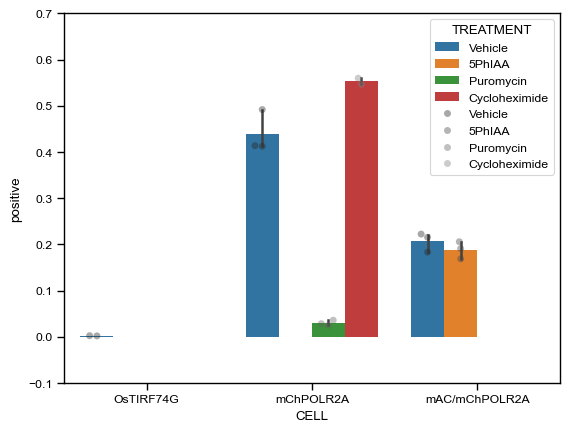

In [118]:
sns.barplot(Colocalisation_Per_Threshold_POLR2A_mCh_only.query('percentile_rouned == 94.9')[['WELL_UNIQUE','CELL','TREATMENT','positive']].groupby(['WELL_UNIQUE','CELL','TREATMENT']).mean(),
            x = 'CELL',
            hue = 'TREATMENT',
            dodge = True,
            y = 'positive')

sns.swarmplot(Colocalisation_Per_Threshold_POLR2A_mCh_only.query('percentile_rouned == 94.9')[['WELL_UNIQUE','CELL','TREATMENT','positive']].groupby(['WELL_UNIQUE','CELL','TREATMENT']).mean(),
            x = 'CELL',
            hue = 'TREATMENT',
              color = 'grey', alpha = 0.4,
            dodge = True,
            y = 'positive')

plt.ylim(-0.1,0.7)